RQ3: Stability and Adaptation

Performance Comparison

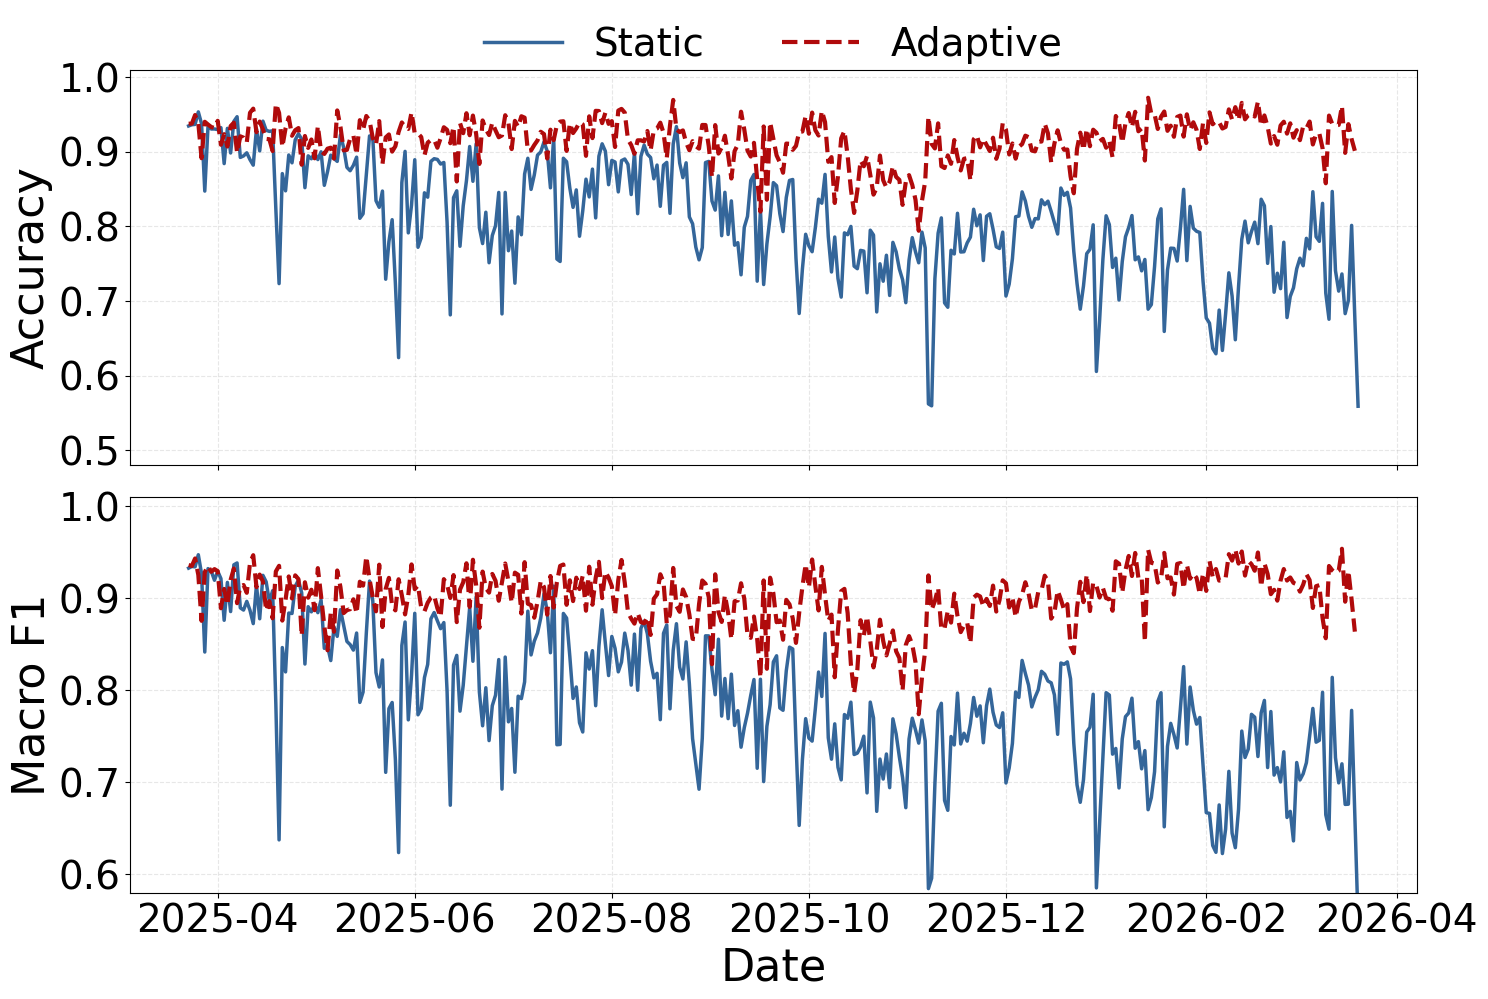

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates

# === Style settings ===
font_main = 32
font_extra = 28
figsize = (15, 10)

color_static = "#34669A"
color_adaptive = "#B00A0B"

# === 1. Load results ===
static = pd.read_csv("../data/res/static/static8.csv")
dynamic = pd.read_csv("../data/rq3/h8/test_blocks.csv")

# === 2. Convert block index to datetime ===
start_time = pd.Timestamp("2025-03-15 00:00:00")

for df in [static, dynamic]:
    df["datetime"] = start_time + pd.to_timedelta(df["block_index"], unit="h")

# === 3. Clean ===
static = static.dropna(subset=["accuracy", "f1_score"])
dynamic = dynamic.dropna(subset=["accuracy", "f1_score"])

# === 4. Aggregate per day ===
def daily_mean(df):
    return (
        df.resample("1D", on="datetime")
          .mean(numeric_only=True)
          .reset_index()
    )

static_day = daily_mean(static)
dynamic_day = daily_mean(dynamic)

# === 5. Plot ===
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=figsize,
    sharex=True
)

# -------------------------
# Accuracy
# -------------------------
ax1.plot(
    static_day["datetime"],
    static_day["accuracy"],
    color=color_static,
    linewidth=2.5,
    label="Static"
)

ax1.plot(
    dynamic_day["datetime"],
    dynamic_day["accuracy"],
    color=color_adaptive,
    linewidth=3.0,
    linestyle="--",
    label="Adaptive"
)

ax1.set_ylabel("Accuracy", fontsize=font_main)
ax1.set_ylim(0.48, 1.01)
ax1.set_yticks(np.arange(0.5, 1.01, 0.1))
ax1.grid(alpha=0.3, linestyle="--")

ax1.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.2),
    ncol=2,
    frameon=False,
    fontsize=font_extra
)

# -------------------------
# F1 Score
# -------------------------
ax2.plot(
    static_day["datetime"],
    static_day["f1_score"],
    color=color_static,
    linewidth=2.5
)

ax2.plot(
    dynamic_day["datetime"],
    dynamic_day["f1_score"],
    color=color_adaptive,
    linewidth=3.0,
    linestyle="--"
)

ax2.set_ylabel("Macro F1", fontsize=font_main)
ax2.set_xlabel("Date", fontsize=font_main)
ax2.set_ylim(0.58, 1.01)
ax2.set_yticks(np.arange(0.6, 1.01, 0.1))
ax2.grid(alpha=0.3, linestyle="--")

# -------------------------
# Axis formatting
# -------------------------
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

ax1.tick_params(axis="both", labelsize=font_extra)
ax2.tick_params(axis="both", labelsize=font_extra)

plt.xticks(rotation=0)

fig.tight_layout()

plt.savefig(
    "../data/rq3/figs/adaptation_accuracy_f1_comparison.pdf",
    bbox_inches="tight"
)

plt.show()

In [15]:
import pandas as pd
files = {
    "Static": "../../LANTERN/data/res/static/static8.csv",
    "Dynamic": "../../LANTERN/data/rq3/h8/test_blocks.csv"
}

summary = []

for name, path in files.items():
    df = pd.read_csv(path)

    # Ensure only test data is used (important for your new pipeline)
    if "data_split" in df.columns:
        df = df[df["data_split"] == "test"]

    # Drop missing rows
    df = df.dropna(subset=["accuracy", "f1_score"])

    metrics = {
        "Accuracy_mean": df["accuracy"].mean(),
        "Accuracy_std": df["accuracy"].std(),
        "F1_mean": df["f1_score"].mean(),
        "F1_std": df["f1_score"].std(),
        "Precision_mean": df["precision"].mean(),
        "Recall_mean": df["recall"].mean(),
        "Retrains": max(df["retrain_id"].nunique() - 1, 0)
    }

    summary.append({"Method": name, **metrics})

summary_df = pd.DataFrame(summary)

print("\n=== Overall Performance Summary ===")
print(summary_df.round(4))

summary_df.to_csv("../data/res/adaptive_summary.csv", index=False)


=== Overall Performance Summary ===
    Method  Accuracy_mean  Accuracy_std  F1_mean  F1_std  Precision_mean  \
0   Static         0.8087        0.1149   0.7878  0.1145          0.7971   
1  Dynamic         0.9166        0.0602   0.9008  0.0678          0.9023   

   Recall_mean  Retrains  
0       0.8159         0  
1       0.9082        94  


#### Monthly Summary

In [ ]:
import re
from pathlib import Path, PurePath
# =========================================================
# Helper: Extract YYYY-MM from file path
# =========================================================
def extract_month(path):
    match = re.search(r"(\d{4}-\d{2})-\d{2}", str(path))
    return match.group(1) if match else None

files = {
    "Static": "../../LANTERN/data/res/static/static8.csv",
    "Dynamic": "../../LANTERN/data/rq3/h8/test_blocks.csv"
}

summary_rows = []

for method, path in files.items():
    df = pd.read_csv(path)
    
    # --- extract date from file path (../data/sequences/YYYY-MM-DD/xxx.csv)
    df["date"] = df["file"].apply(lambda x: Path(x).parts[-2])
    df["month"] = df["date"].str.slice(0, 7)  # YYYY-MM

    grouped = (
        df.groupby("month")
          .agg(
              Accuracy_mean=("accuracy", "mean"),
              Accuracy_std=("accuracy", "std"),
              F1_mean=("f1_score", "mean"),
              F1_std=("f1_score", "std"),
              Precision_mean=("precision", "mean"),
              Precision_std=("precision", "std"),
              Recall_mean=("recall", "mean"),
              Recall_std=("recall", "std"),
              Entropy_mean=("entropy_score", "mean"),
              Entropy_std=("entropy_score", "std"),
              LMT_mean=("lmt_mean_score", "mean"),
              LMT_std=("lmt_mean_score", "std"),
              Retrains=("retrain_id", lambda x: x.nunique() - 1),
          )
          .reset_index()
    )
    grouped["Method"] = method
    summary_rows.append(grouped)

summary_df = pd.concat(summary_rows, ignore_index=True)
summary_df = summary_df[
    ["Method", "month", "Accuracy_mean", "Accuracy_std", "F1_mean", "F1_std",
     "Precision_mean","Precision_std", "Recall_mean", "Recall_std","Entropy_mean", "Entropy_std",
     "LMT_mean", "LMT_std", "Retrains"]
]
summary_df.to_csv("../../LANTERN/data/rq3/monthly_drift_summary.csv", index=False)
print(" Monthly drift + performance summary saved → ../data/rq3/monthly_drift_summary.csv")

# --- Optional: print preview ---
pd.set_option("display.max_rows", None)
print(summary_df.round(4))


 Monthly drift + performance summary saved → ../data/res/monthly_drift_summary.csv
     Method    month  Accuracy_mean  Accuracy_std  F1_mean  F1_std  \
0    Static  2025-03         0.9266        0.0500   0.9219  0.0525   
1    Static  2025-04         0.8971        0.0724   0.8824  0.0930   
2    Static  2025-05         0.8496        0.1061   0.8306  0.1081   
3    Static  2025-06         0.8256        0.1126   0.8158  0.1069   
4    Static  2025-07         0.8496        0.0882   0.8266  0.0892   
5    Static  2025-08         0.8630        0.0944   0.8229  0.0994   
6    Static  2025-09         0.8047        0.1023   0.7826  0.1029   
7    Static  2025-10         0.7636        0.0982   0.7446  0.1003   
8    Static  2025-11         0.7616        0.1032   0.7449  0.0946   
9    Static  2025-12         0.7949        0.1006   0.7792  0.0996   
10   Static  2026-01         0.7561        0.1147   0.7396  0.1098   
11   Static  2026-02         0.7425        0.1058   0.7147  0.0973   
12   St

FileNotFoundError: [Errno 2] No such file or directory: '../data/ana/monthly_drift_tripleaxis.pdf'

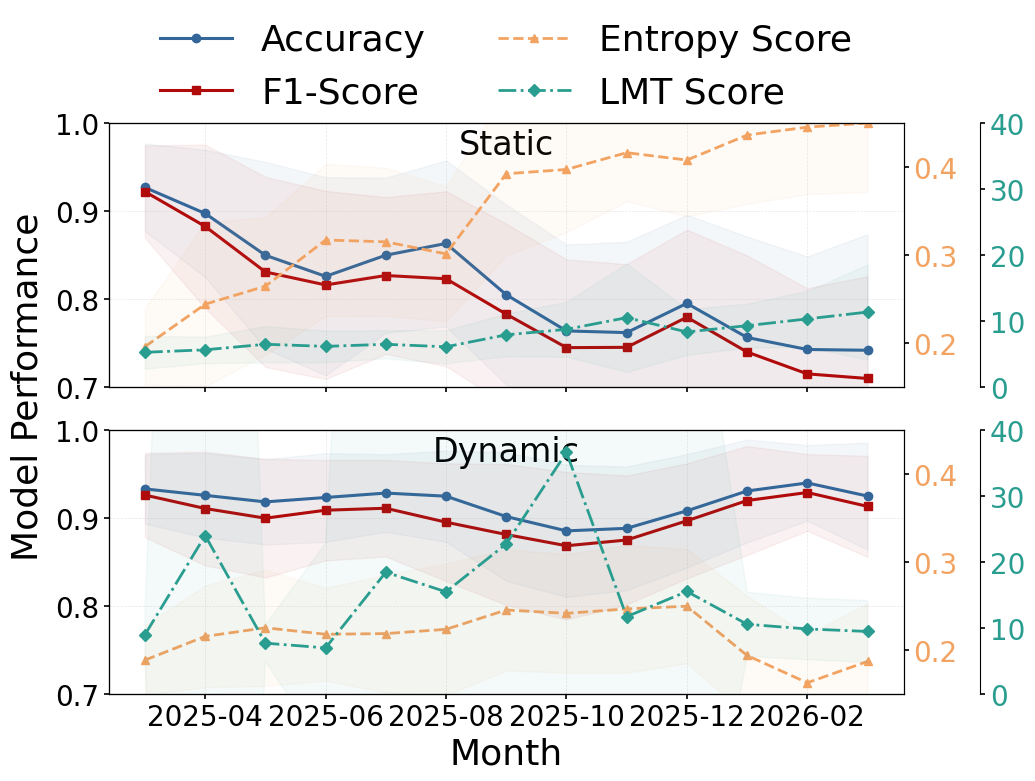

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Load monthly summary ---
df = pd.read_csv("../../LANTERN/data/rq3/monthly_drift_summary.csv")
df["month"] = pd.to_datetime(df["month"])
df = df.sort_values("month")

methods = df["Method"].unique()
colors_perf = {"Accuracy": "#34669A", "F1": "#B00A0B"}
color_entropy = "#f3a361"
color_lmt = "#299d8f"

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for i, method in enumerate(methods):
    ax1 = axes[i]
    sub = df[df["Method"] == method]
    months = sub["month"].dt.strftime("%Y-%m")

    # --- Left axis: Performance (Accuracy, F1) ---
    ax1.plot(months, sub["Accuracy_mean"], color=colors_perf["Accuracy"],
             marker="o", linewidth=2.2, label="Accuracy")
    ax1.fill_between(months,
                     sub["Accuracy_mean"] - sub["Accuracy_std"],
                     sub["Accuracy_mean"] + sub["Accuracy_std"],
                     color=colors_perf["Accuracy"], alpha=0.05)

    ax1.plot(months, sub["F1_mean"], color=colors_perf["F1"],
             marker="s", linewidth=2.2, label="F1-Score")
    ax1.fill_between(months,
                     sub["F1_mean"] - sub["F1_std"],
                     sub["F1_mean"] + sub["F1_std"],
                     color=colors_perf["F1"], alpha=0.05)
    '''
    if i == 0:
        ax1.set_ylabel("Model Performance", fontsize=26, color="#1f1f1f")
    else:
        ax1.set_ylabel(" ")
    '''

    ax1.set_ylim(0.7, 1.0)
    ax1.grid(alpha=0.3, linestyle="--", linewidth=0.5)

    # --- Right axis (1): Entropy Drift ---
    ax2 = ax1.twinx()
    ax2.plot(months, sub["Entropy_mean"], color=color_entropy,
             linestyle="--", linewidth=2.0, marker="^", label="Entropy Score")
    ax2.fill_between(months,
                     sub["Entropy_mean"] - sub["Entropy_std"],
                     sub["Entropy_mean"] + sub["Entropy_std"],
                     color=color_entropy, alpha=0.05)
    # ax2.set_ylabel("Entropy Score", fontsize=16, color=color_entropy)
    ax2.tick_params(axis="y", labelcolor=color_entropy)
    ax2.set_ylim(0.15, 0.45)

    # --- Right axis (2): LMT Drift (further right) ---
    ax3 = ax1.twinx()
    ax3.spines["right"].set_position(("outward", 55))  # offset outward
    ax3.plot(months, sub["LMT_mean"], color=color_lmt,
             linestyle="-.", linewidth=2.0, marker="D", label="LMT Score")
    ax3.fill_between(months,
                     sub["LMT_mean"] - sub["LMT_std"],
                     sub["LMT_mean"] + sub["LMT_std"],
                     color=color_lmt, alpha=0.05)
    # ax3.set_ylabel("LMT Score", fontsize=16, color=color_lmt)
    ax3.tick_params(axis="y", labelcolor=color_lmt)
    ax3.set_ylim(0, 40)

    # --- Title inside the panel ---
    ax1.text(
        0.5, 0.98, method, 
        transform=ax1.transAxes, 
        fontsize=24,
        va="top", ha="center",
    )


    # --- Combined legend ---
    if i == 0:
        lines, labels = [], []
        for ax in [ax1, ax2, ax3]:
            lns, lbs = ax.get_legend_handles_labels()
            lines += lns
            labels += lbs
        ax1.legend(lines, labels, loc="upper center", ncol=2,
                   frameon=False, fontsize=26, bbox_to_anchor=(0.5, 1.5))

    # --- Make axis ticks larger and clearer ---
    ax1.tick_params(axis="x", labelsize=20, width=1.2)
    ax1.tick_params(axis="y", labelsize=20, width=1.2)
    ax2.tick_params(axis="y", labelsize=20, width=1.2)
    ax2.tick_params(axis="y", labelsize=20, width=1.2, labelcolor=color_entropy)
    ax3.tick_params(axis="y", labelsize=20, width=1.2, labelcolor=color_lmt)

# --- Shared X-axis ---
axes[-1].set_xlabel("Month", fontsize=26)

fig.text(-0.03, 0.5, "Model Performance", va="center", rotation="vertical", fontsize=26)

# Only show every second month label (e.g., Mar, May, Jul, Sep)
tick_idx = np.arange(1, len(months), 2)
axes[-1].set_xticks(tick_idx)
axes[-1].set_xticklabels([months.iloc[i] for i in tick_idx], fontsize=20)

plt.tight_layout()
plt.savefig("../data/rq3/figs/monthly_drift_tripleaxis.pdf", bbox_inches="tight")
plt.show()
